[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emersonnjsantos/visao_computacional/blob/main/ATIVIDADE_1/visao_computacional_mini_dataset/notebooks/relatorio_atividade_2_projeto.ipynb)


# Atividade 2 - Suavização, Remoção de Ruído e Detecção de Bordas
## Parte 1 — Seleção das imagens

De acordo com os requisitos, foram selecionadas 2 imagens da Classe A e 2 imagens da Classe B que apresentam degradações visíveis[cite: 1].

### Imagem 1 (Classe A)
* **Nome da imagem:** img002_original.jpg
* **Classe:** Classe A - Plantas e Folhagens
* **Tipo de degradação observada:** Baixa qualidade visual, falta de nitidez geral (blur) e baixo contraste[cite: 1].
* **Sua hipótese sobre a origem do ruído:** A câmera apresentou dificuldade de foco automático (focus hunting) ao tentar mapear a textura complexa das folhas miúdas. Além disso, a iluminação difusa ou o processamento automático do smartphone parece ter "lavado" a imagem, reduzindo o contraste e gerando uma aparência opaca e de baixa qualidade visual.

### Imagem 2 (Classe A)
* **Nome da imagem:** img005_original.jpg
* **Classe:** Classe A - Plantas e Folhagens
* **Tipo de degradação observada:** Baixa qualidade visual, desfoque severo e leve granulação nas áreas de sombra das folhas roxas[cite: 1].
* **Sua hipótese sobre a origem do ruído:** A captura foi realizada muito próxima ao alvo (tentativa de macro) sem a iluminação ideal. A lente não conseguiu cravar o foco na flor menor, gerando o desfoque. Nas áreas mais escuras da folhagem roxa, o algoritmo da câmera provavelmente elevou o ganho (ISO) para compensar a falta de luz, introduzindo granulação visível.

### Imagem 3 (Classe B)
* **Nome da imagem:** img008_original.jpg
* **Classe:** Classe B - Plantas e Folhagens
* **Tipo de degradação observada:** Baixa qualidade visual e pequenas variações aleatórias de intensidade nas superfícies das folhas longas[cite: 1].
* **Sua hipótese sobre a origem do ruído:** A imagem apresenta um desfoque geral que indica um leve tremor do usuário durante a captura (motion blur) combinado com uma possível dificuldade do algoritmo de autofoco em cravar a nitidez devido ao contraste entre o fundo escuro e a flor clara. As folhas verdes, que deveriam apresentar intensidades mais uniformes, mostram pequenas variações aleatórias causadas pelo ruído do sensor (ganho de ISO) operando em um ambiente com iluminação não ideal.

### Imagem 4 (Classe B)
* **Nome da imagem:** img009_original.jpg
* **Classe:** Classe B - Plantas e Folhagens
* **Tipo de degradação observada:** Baixa qualidade visual severa e compressão visível nas áreas de transição de cor do fundo[cite: 1].
* **Sua hipótese sobre a origem do ruído:** Esta imagem representa uma falha clássica de foco em fotografias de proximidade (macro). A lente da câmera foi posicionada em uma distância inferior ao seu limite mínimo de foco físico, impossibilitando a nitidez do trevo central. Consequentemente, as áreas severamente desfocadas ao fundo sofrem com os artefatos do algoritmo de compressão JPEG, que frequentemente agrupa pixels de gradientes suaves e desfocados em blocos visíveis, prejudicando a qualidade visual.

In [19]:
!git clone https://github.com/emersonnjsantos/visao_computacional.git

fatal: destination path 'visao_computacional' already exists and is not an empty directory.


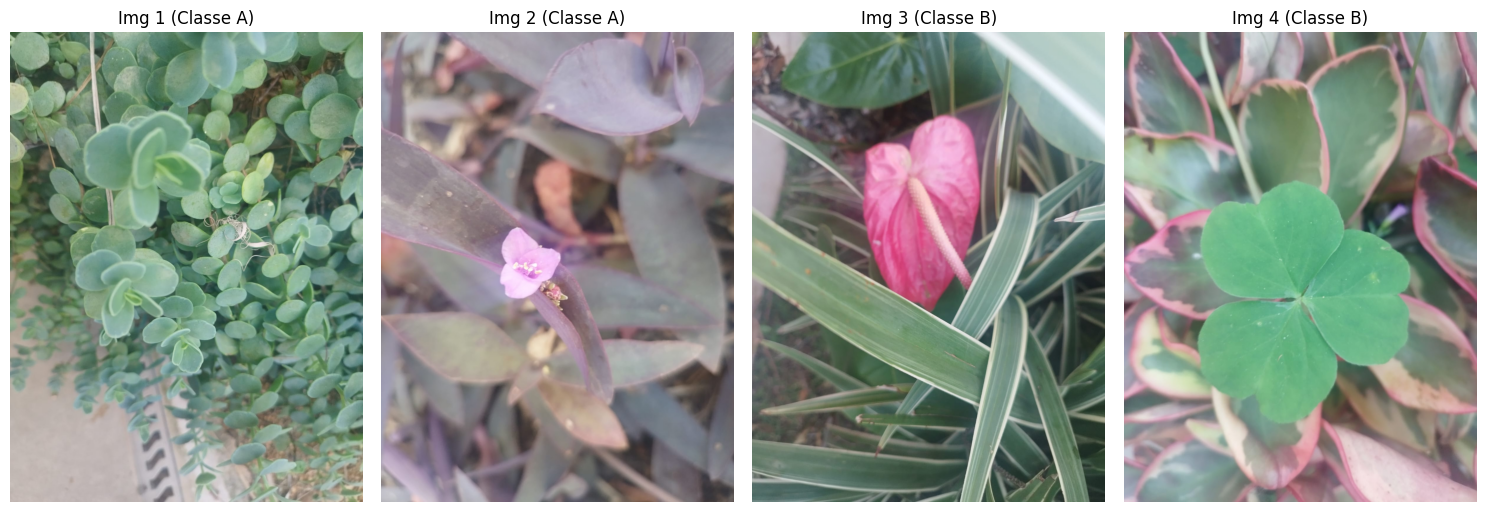

In [20]:
import cv2
import matplotlib.pyplot as plt
import os

# Definindo a base do caminho do Colab após o clone do seu GitHub
base_path = '/content/visao_computacional/ATIVIDADE_1/visao_computacional_mini_dataset/dataset'

caminhos = [
    f'{base_path}/classe_A/img002_original.jpg',
    f'{base_path}/classe_A/img005_original.jpg',
    f'{base_path}/classe_B/img008_original.jpg',
    f'{base_path}/classe_B/img009_original.jpg'
]

titulos = ['Img 1 (Classe A)', 'Img 2 (Classe A)', 'Img 3 (Classe B)', 'Img 4 (Classe B)']

plt.figure(figsize=(15, 5))

for i in range(4):
    img = cv2.imread(caminhos[i])

    if img is not None:
        # Convertendo de BGR para RGB para visualização correta no Matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, 4, i+1)
        plt.imshow(img_rgb)
        plt.title(titulos[i])
        plt.axis('off')
    else:
        print(f"Erro ao carregar o caminho: {caminhos[i]}\nVerifique se o git clone funcionou.")

plt.tight_layout()
plt.show()

## Parte 2 — Aplicação de filtros de suavização e Análise Teórica

Com base na aplicação dos filtros espaciais sobre a imagem em tons de cinza, e fundamentando-se na teoria de processamento no domínio espacial, observou-se:

* **Qual filtro reduziu mais o ruído?**
O **Filtro da Mediana (Kernel 5x5)** apresentou a maior robustez na redução do ruído. Segundo a literatura base, o filtro da mediana é uma operação espacial não linear que substitui o valor do pixel central pelo valor mediano da vizinhança ordenada, o que o torna altamente robusto a valores extremos (outliers) sem ser influenciado por eles[cite: 2]. O **Filtro da Média**, por ser uma operação linear que atribui pesos iguais a toda a vizinhança, reduz ruídos de baixa intensidade, mas é altamente sensível a outliers e não consegue distinguir ruído de estrutura relevante[cite: 2]. O aumento do tamanho do kernel de 3x3 para 5x5 intensificou a suavização em todos os métodos aplicados[cite: 2].

* **Qual preservou melhor as bordas?**
O **Filtro Gaussiano (especialmente com $\sigma=1$)** e o **Filtro da Mediana (3x3)** apresentaram a melhor preservação de bordas[cite: 2]. O material define explicitamente que o Filtro Gaussiano preserva melhor as bordas em comparação ao filtro da média porque atribui maior peso aos pixels mais próximos do centro e menor peso aos mais distantes, respeitando a estrutura espacial[cite: 2]. O Filtro da Mediana também se destaca na preservação de bordas por não realizar somas ponderadas[cite: 2]. Em contrapartida, o Filtro da Média causou a perda de detalhes finos e o consequente espessamento e borramento das bordas da folhagem[cite: 2].

* **O que aconteceu com a variância dos níveis de cinza da imagem?**
A variância dos níveis de cinza da imagem **diminuiu** após a aplicação dos filtros. O pré-processamento atua como uma transformação estatística da variável de entrada que altera a distribuição dos valores de intensidade[cite: 2]. Filtros de suavização lineares (Média e Gaussiano) atuam como filtros passa-baixa, o que significa que eles atenuam as componentes de alta frequência, ou seja, as variações rápidas e abruptas de intensidade[cite: 2]. Ao atenuar essas transições e homogeneizar a vizinhança, a dispersão global dos níveis de cinza em relação à média é reduzida, refletindo-se matematicamente na queda do valor da variância.

--- ANÁLISE DE VARIÂNCIA DOS NÍVEIS DE CINZA: Img002 (Classe A) ---
Original:        1323.92
Média 3x3:       1307.50 | Média 5x5:   1285.17
Gaussiano sig=1: 1301.80 | Gaussiano sig=3: 1219.36
Mediana 3x3:     1317.65 | Mediana 5x5: 1308.77
-----------------------------------------------------------------


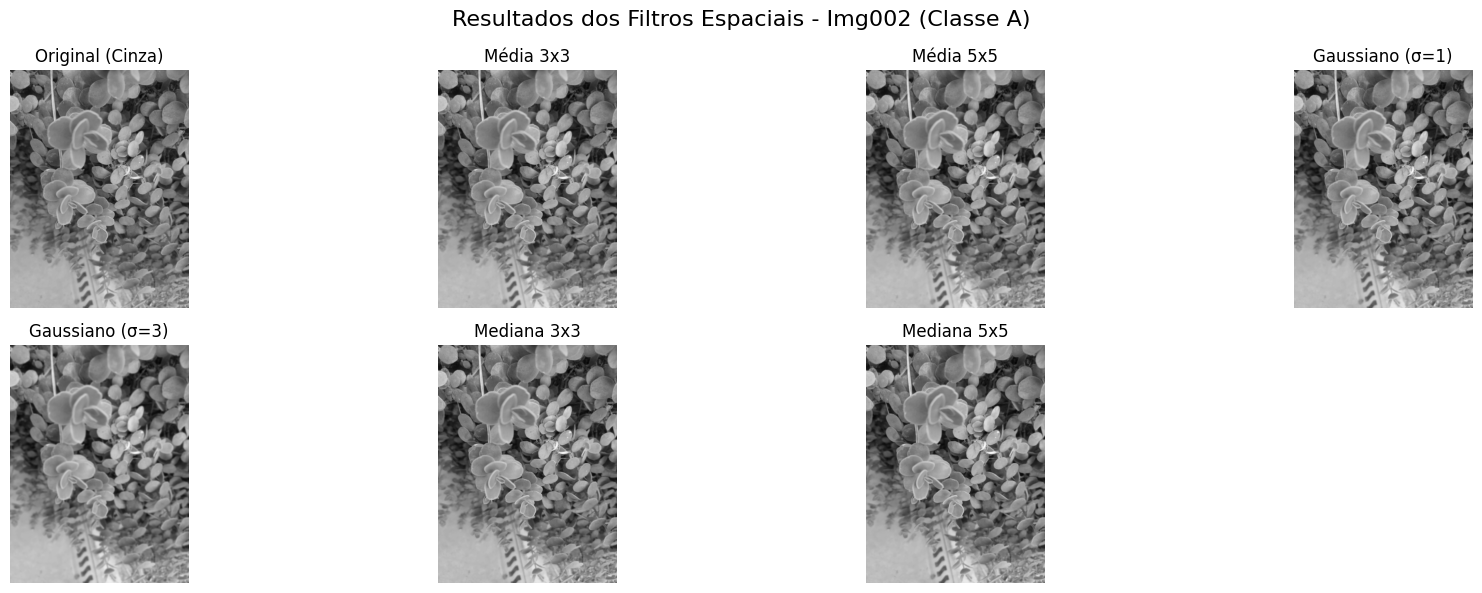

--- ANÁLISE DE VARIÂNCIA DOS NÍVEIS DE CINZA: Img005 (Classe A) ---
Original:        1123.26
Média 3x3:       1120.53 | Média 5x5:   1116.15
Gaussiano sig=1: 1119.50 | Gaussiano sig=3: 1099.64
Mediana 3x3:     1122.08 | Mediana 5x5: 1120.03
-----------------------------------------------------------------


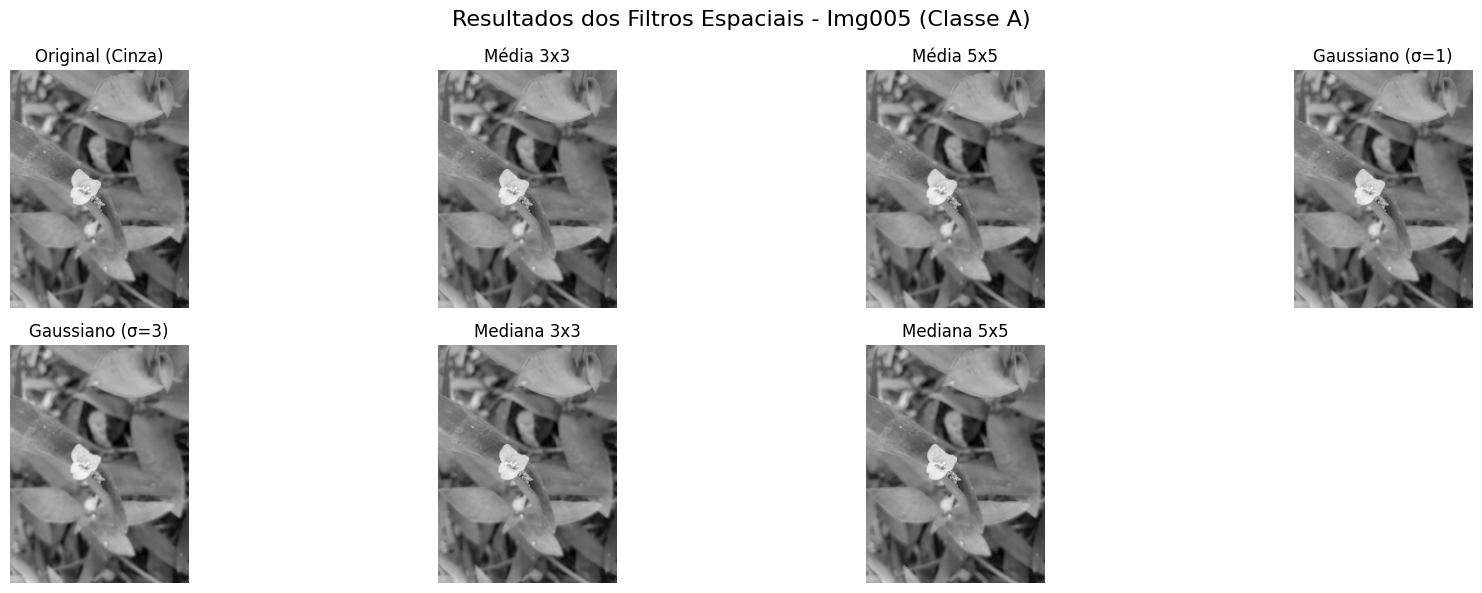

--- ANÁLISE DE VARIÂNCIA DOS NÍVEIS DE CINZA: Img008 (Classe B) ---
Original:        1993.77
Média 3x3:       1979.49 | Média 5x5:   1957.94
Gaussiano sig=1: 1974.08 | Gaussiano sig=3: 1887.08
Mediana 3x3:     1989.92 | Mediana 5x5: 1984.21
-----------------------------------------------------------------


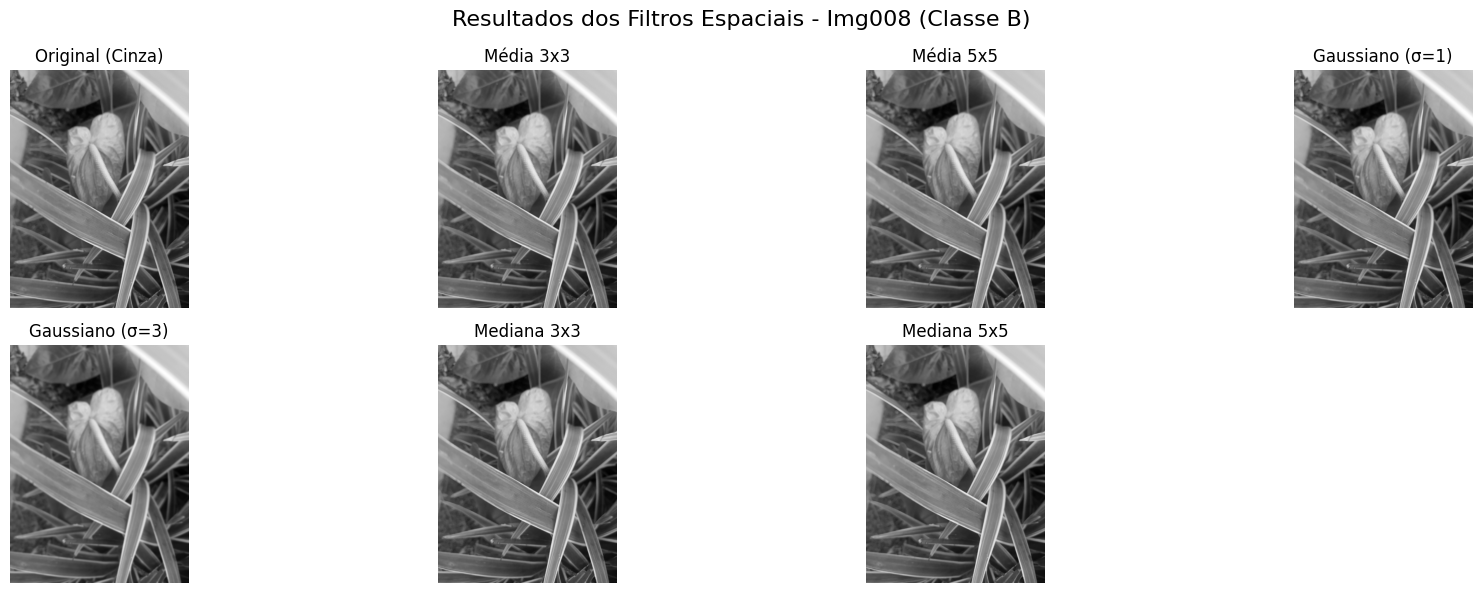

--- ANÁLISE DE VARIÂNCIA DOS NÍVEIS DE CINZA: Img009 (Classe B) ---
Original:        1173.92
Média 3x3:       1170.37 | Média 5x5:   1164.21
Gaussiano sig=1: 1168.93 | Gaussiano sig=3: 1138.81
Mediana 3x3:     1172.68 | Mediana 5x5: 1170.73
-----------------------------------------------------------------


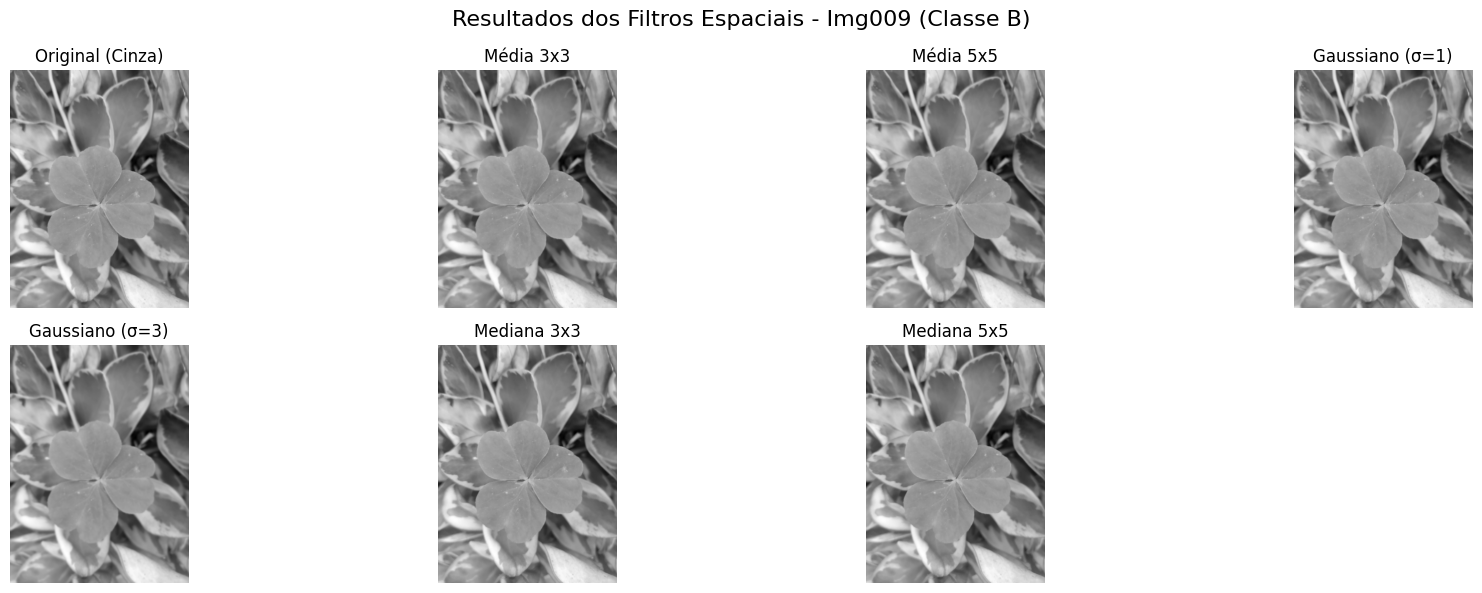

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Garantindo os caminhos das 4 imagens selecionadas na Parte 1
caminhos = [
    f'{base_path}/classe_A/img002_original.jpg',
    f'{base_path}/classe_A/img005_original.jpg',
    f'{base_path}/classe_B/img008_original.jpg',
    f'{base_path}/classe_B/img009_original.jpg'
]

nomes_imagens = ['Img002 (Classe A)', 'Img005 (Classe A)', 'Img008 (Classe B)', 'Img009 (Classe B)']

# O laço garante que os filtros sejam aplicados PARA CADA IMAGEM.
for idx, caminho in enumerate(caminhos):

    # 1. Leitura no Domínio Espacial (Escala de Cinza)
    # Analisamos a matriz de intensidades de 0 a 255.
    img_gray = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)

    if img_gray is None:
        print(f"Erro ao ler a imagem: {caminho}")
        continue

    # 2. Operações Baseadas em Vizinhança LINEARES (Convolução)
    # Filtro da Média (Suavização uniforme - passa-baixa)
    media_3x3 = cv2.blur(img_gray, (3, 3))
    media_5x5 = cv2.blur(img_gray, (5, 5))

    # Filtro Gaussiano (Suavização ponderada baseada na distribuição normal)
    # O (0,0) indica que o OpenCV calculará o tamanho do kernel automaticamente com base no Sigma.
    gauss_sig1 = cv2.GaussianBlur(img_gray, (0, 0), sigmaX=1)
    gauss_sig3 = cv2.GaussianBlur(img_gray, (0, 0), sigmaX=3)

    # 3. Operações Baseadas em Vizinhança NÃO LINEARES
    # Filtro da Mediana (Robusto a ruído impulsivo e outliers)
    mediana_3x3 = cv2.medianBlur(img_gray, 3)
    mediana_5x5 = cv2.medianBlur(img_gray, 5)

    # 4. Cálculo Estatístico: Variância dos níveis de cinza
    var_orig = np.var(img_gray)
    var_m3 = np.var(media_3x3)
    var_m5 = np.var(media_5x5)
    var_g1 = np.var(gauss_sig1)
    var_g3 = np.var(gauss_sig3)
    var_med3 = np.var(mediana_3x3)
    var_med5 = np.var(mediana_5x5)

    print(f"--- ANÁLISE DE VARIÂNCIA DOS NÍVEIS DE CINZA: {nomes_imagens[idx]} ---")
    print(f"Original:        {var_orig:.2f}")
    print(f"Média 3x3:       {var_m3:.2f} | Média 5x5:   {var_m5:.2f}")
    print(f"Gaussiano sig=1: {var_g1:.2f} | Gaussiano sig=3: {var_g3:.2f}")
    print(f"Mediana 3x3:     {var_med3:.2f} | Mediana 5x5: {var_med5:.2f}")
    print("-" * 65)

    # 5. Visualização
    titulos = ['Original (Cinza)', 'Média 3x3', 'Média 5x5',
               'Gaussiano (σ=1)', 'Gaussiano (σ=3)',
               'Mediana 3x3', 'Mediana 5x5']
    imagens = [img_gray, media_3x3, media_5x5, gauss_sig1, gauss_sig3, mediana_3x3, mediana_5x5]

    plt.figure(figsize=(18, 6))
    plt.suptitle(f"Resultados dos Filtros Espaciais - {nomes_imagens[idx]}", fontsize=16)

    for i in range(7):
        plt.subplot(2, 4, i+1)
        # O cmap='gray' assegura que a visualização seja estritamente nas intensidades luminosas
        plt.imshow(imagens[i], cmap='gray')
        plt.title(titulos[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

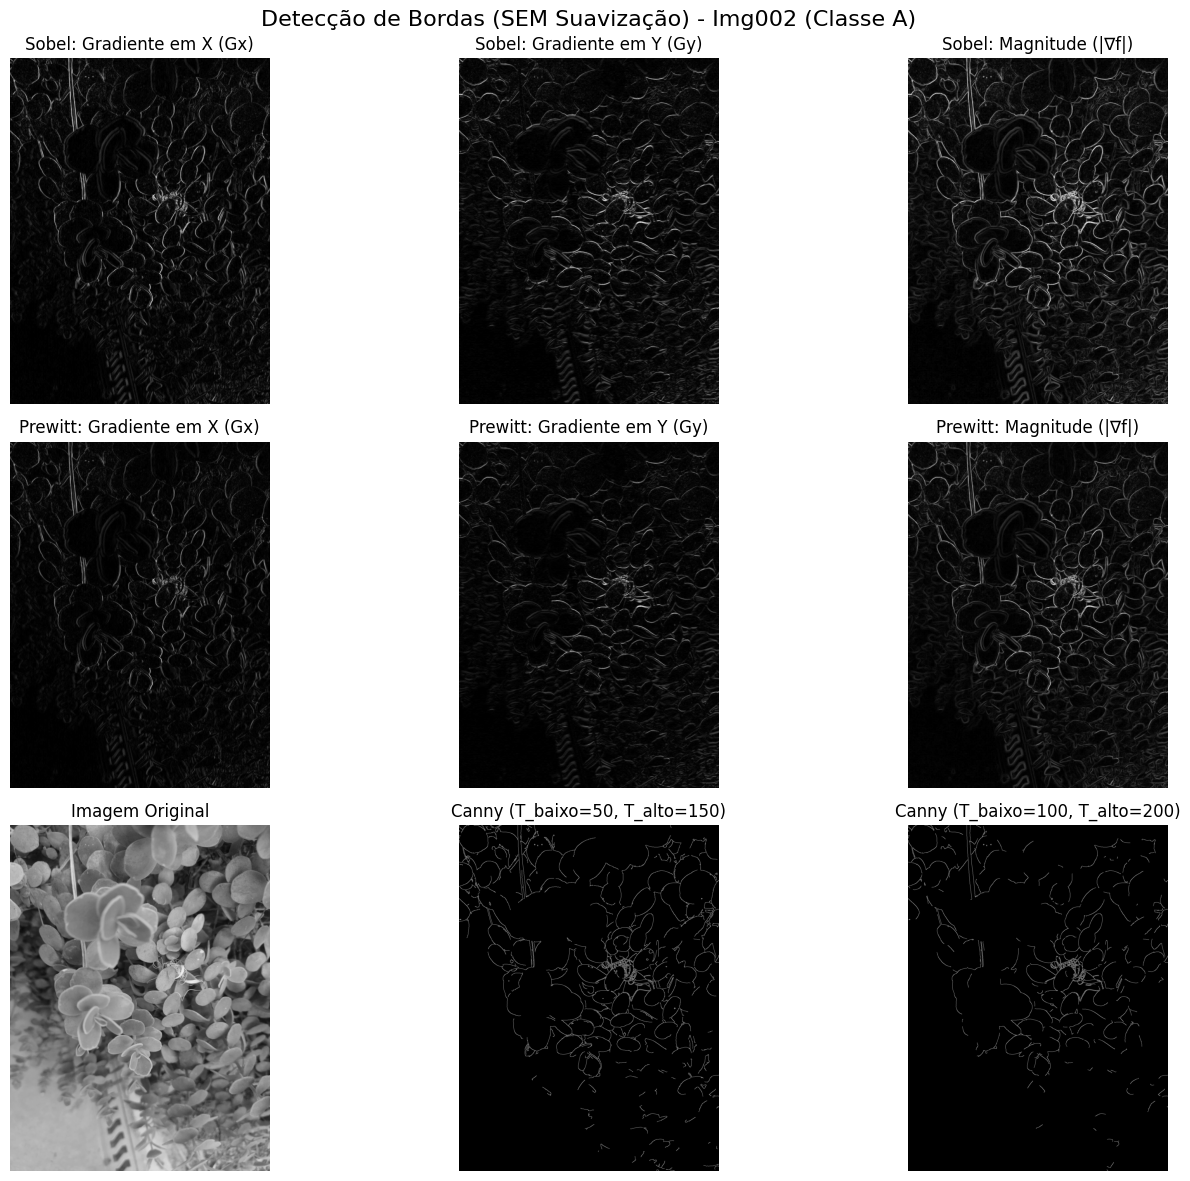

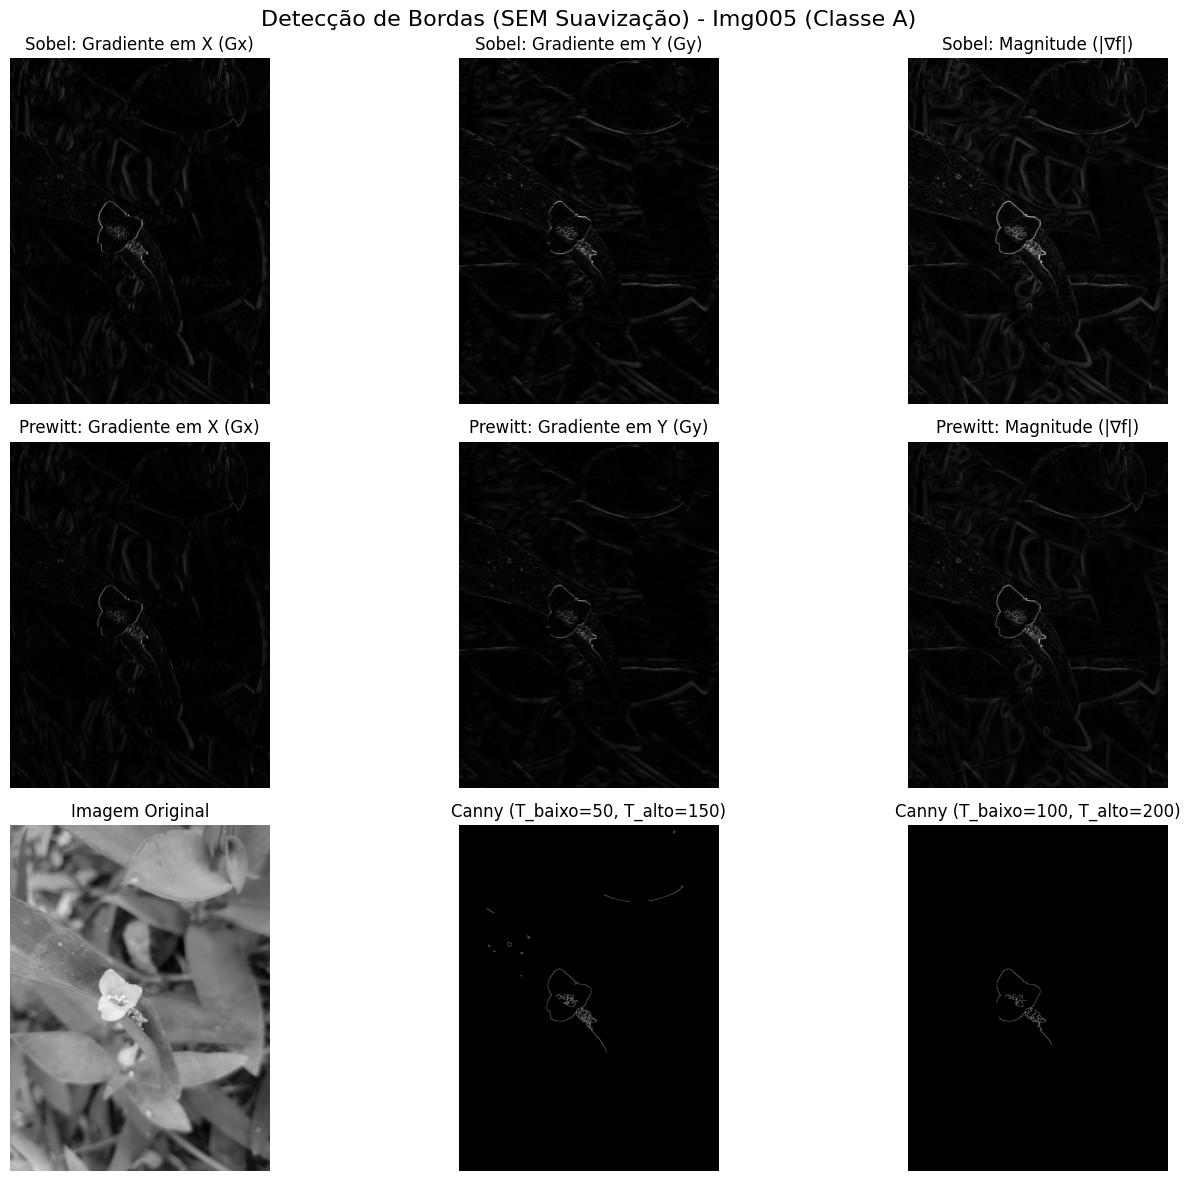

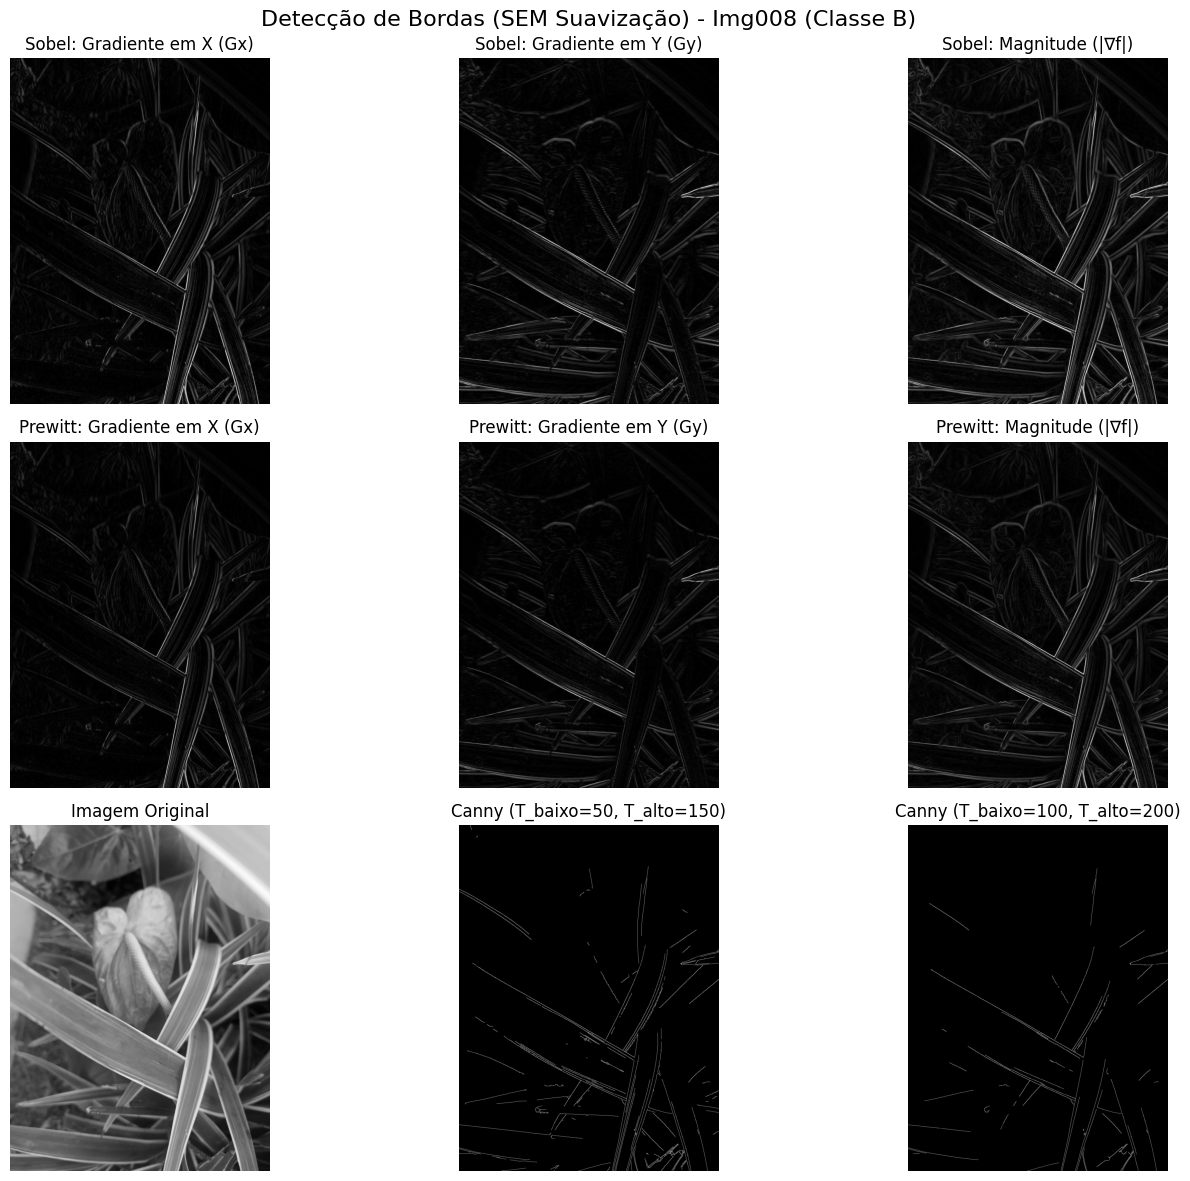

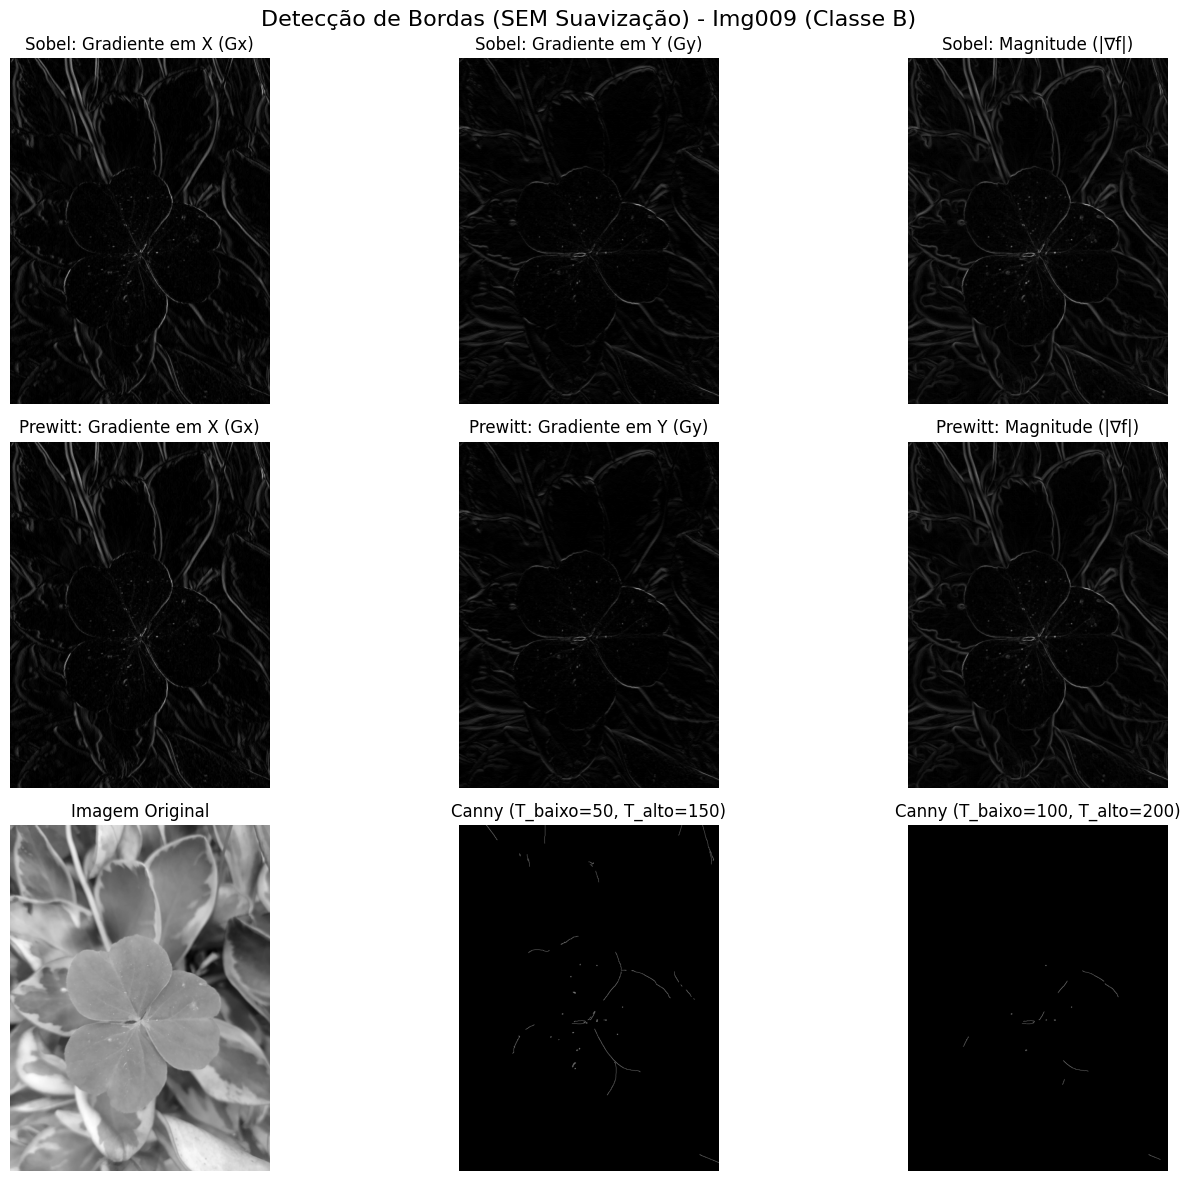

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Usei a mesma lista de caminhos do passo anterior
for idx, caminho in enumerate(caminhos):
    img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
    if img is None: continue

    # ---------------------------------------------------------
    # 1. Operador de Sobel (Derivada com leve suavização central)
    # usei CV_64F para não perder as derivadas negativas antes de calcular a magnitude
    # ---------------------------------------------------------
    sobel_x_64 = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y_64 = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    sobel_x = cv2.convertScaleAbs(sobel_x_64)
    sobel_y = cv2.convertScaleAbs(sobel_y_64)
    # Magnitude exata do gradiente
    sobel_mag = cv2.magnitude(sobel_x_64, sobel_y_64)
    sobel_mag = cv2.convertScaleAbs(sobel_mag)

    # ---------------------------------------------------------
    # 2. Operador de Prewitt (Derivada com pesos uniformes)
    # ---------------------------------------------------------
    kernel_prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    kernel_prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)

    prewitt_x_64 = cv2.filter2D(img, cv2.CV_64F, kernel_prewitt_x)
    prewitt_y_64 = cv2.filter2D(img, cv2.CV_64F, kernel_prewitt_y)

    prewitt_x = cv2.convertScaleAbs(prewitt_x_64)
    prewitt_y = cv2.convertScaleAbs(prewitt_y_64)
    prewitt_mag = cv2.magnitude(prewitt_x_64, prewitt_y_64)
    prewitt_mag = cv2.convertScaleAbs(prewitt_mag)

    # ---------------------------------------------------------
    # 3. Detector de Canny (Com dois conjuntos de limiares para teste)
    # ---------------------------------------------------------
    canny_baixo = cv2.Canny(img, 50, 150)
    canny_alto = cv2.Canny(img, 100, 200)

    # ---------------------------------------------------------
    # Visualização em Grid 3x3
    # ---------------------------------------------------------
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    fig.suptitle(f"Detecção de Bordas (SEM Suavização) - {nomes_imagens[idx]}", fontsize=16)

    # Linha 1: Sobel
    axes[0, 0].imshow(sobel_x, cmap='gray'); axes[0, 0].set_title('Sobel: Gradiente em X (Gx)')
    axes[0, 1].imshow(sobel_y, cmap='gray'); axes[0, 1].set_title('Sobel: Gradiente em Y (Gy)')
    axes[0, 2].imshow(sobel_mag, cmap='gray'); axes[0, 2].set_title('Sobel: Magnitude (|∇f|)')

    # Linha 2: Prewitt
    axes[1, 0].imshow(prewitt_x, cmap='gray'); axes[1, 0].set_title('Prewitt: Gradiente em X (Gx)')
    axes[1, 1].imshow(prewitt_y, cmap='gray'); axes[1, 1].set_title('Prewitt: Gradiente em Y (Gy)')
    axes[1, 2].imshow(prewitt_mag, cmap='gray'); axes[1, 2].set_title('Prewitt: Magnitude (|∇f|)')

    # Linha 3: Original e Canny
    axes[2, 0].imshow(img, cmap='gray'); axes[2, 0].set_title('Imagem Original')
    axes[2, 1].imshow(canny_baixo, cmap='gray'); axes[2, 1].set_title('Canny (T_baixo=50, T_alto=150)')
    axes[2, 2].imshow(canny_alto, cmap='gray'); axes[2, 2].set_title('Canny (T_baixo=100, T_alto=200)')

    for ax in axes.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## Parte 3 — Detecção de Bordas (sem suavização prévia)

A aplicação direta dos operadores de detecção de bordas sobre as imagens originais, que carregam ruídos inerentes ao processo de captura fotográfica, demonstrou os seguintes comportamentos teóricos e práticos:

* **Presença de bordas falsas:**
Como a imagem é modelada como uma função discreta e as bordas são detectadas pela aproximação da primeira derivada (gradiente), qualquer oscilação de alta frequência (ruído térmico ou granulação) gerou picos na derivada, sendo erroneamente classificados como bordas[cite: 2]. Isso resultou em imagens poluídas, onde texturas sutis e ruídos de ISO das folhas foram registrados como contornos intensos. No método de **Canny** com limiares mais baixos ($T_{baixo}=50, T_{alto}=150$), o algoritmo de limiarização por histerese classificou muitos desses ruídos como bordas fracas conectadas, criando rastros falsos ao longo das texturas da imagem[cite: 2].

* **Sensibilidade ao ruído:**
Tanto o Prewitt quanto o Sobel apresentaram alta contaminação visual pelo ruído. No entanto, em conformidade com a literatura, o **Operador de Prewitt** mostrou-se mais sensível ao ruído por utilizar pesos uniformes na sua máscara de convolução[cite: 2]. O **Operador de Sobel** demonstrou ser ligeiramente mais robusto por possuir o peso 2 na linha central de seu kernel ($G_x$ e $G_y$), o que introduz um efeito intrínseco de suavização durante o cálculo do gradiente, atenuando parcialmente as flutuações pontuais de intensidade[cite: 2].

* **Comparação visual entre os métodos:**
  * **Espessura:** Sobel e Prewitt geraram bordas visivelmente grossas e difusas, uma vez que apenas calculam a magnitude do gradiente sem nenhum refinamento estrutural[cite: 2]. O Canny gerou bordas extremamente finas (espessura de 1 pixel), graças à sua etapa de *Supressão de Não-Máximos*, que zera qualquer pixel que não seja o pico máximo local na direção do gradiente[cite: 2].
  * **Direcionalidade:** Os gradientes em $X$ ($S_x$ e $P_x$) destacaram exclusivamente as linhas e transições verticais (como as hastes das plantas), enquanto os gradientes em $Y$ ($S_y$ e $P_y$) evidenciaram apenas os contornos horizontais[cite: 2]. A magnitude combinou ambos para formar a estrutura completa.
  * **Controle no Canny:** Ao elevar os limiares no Canny para ($T_{baixo}=100, T_{alto}=200$), a presença de bordas falsas e ruído impulsivo caiu drasticamente, mas ao custo da continuidade das bordas reais: contornos legítimos e fracos das folhas que não estavam conectados a uma borda forte foram descartados pela histerese, fragmentando a estrutura dos objetos[cite: 2].

<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_577/541926570.py:34: SyntaxWarning: invalid escape sequence '\s'
  axes[0, 1].imshow(img_suavizada, cmap='gray'); axes[0, 1].set_title('Suavizada (Gaussiano $\sigma=1$)')


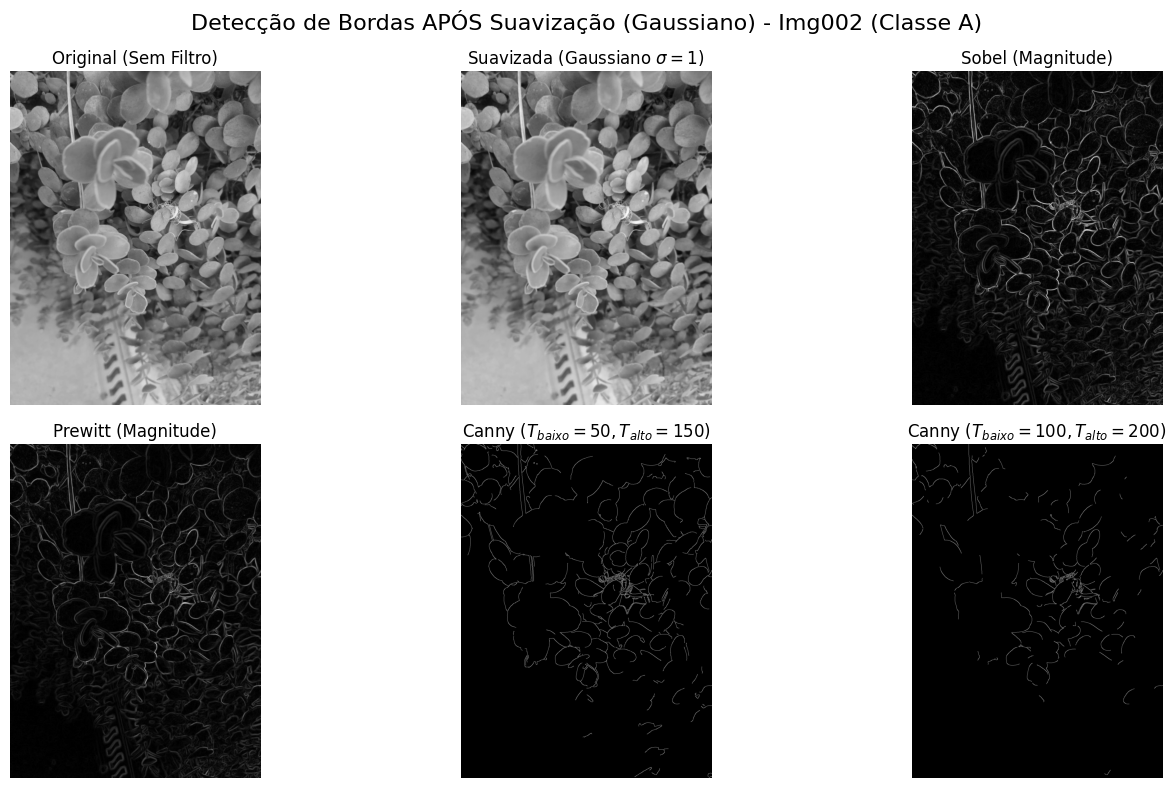

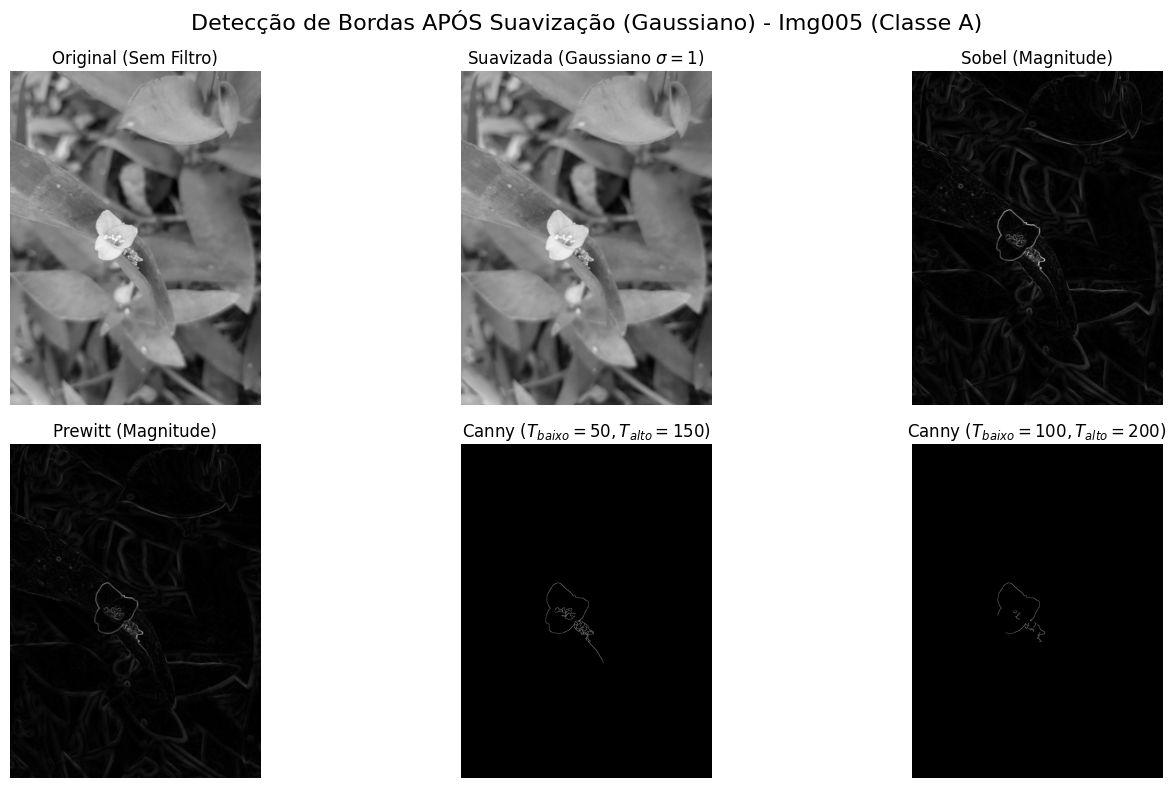

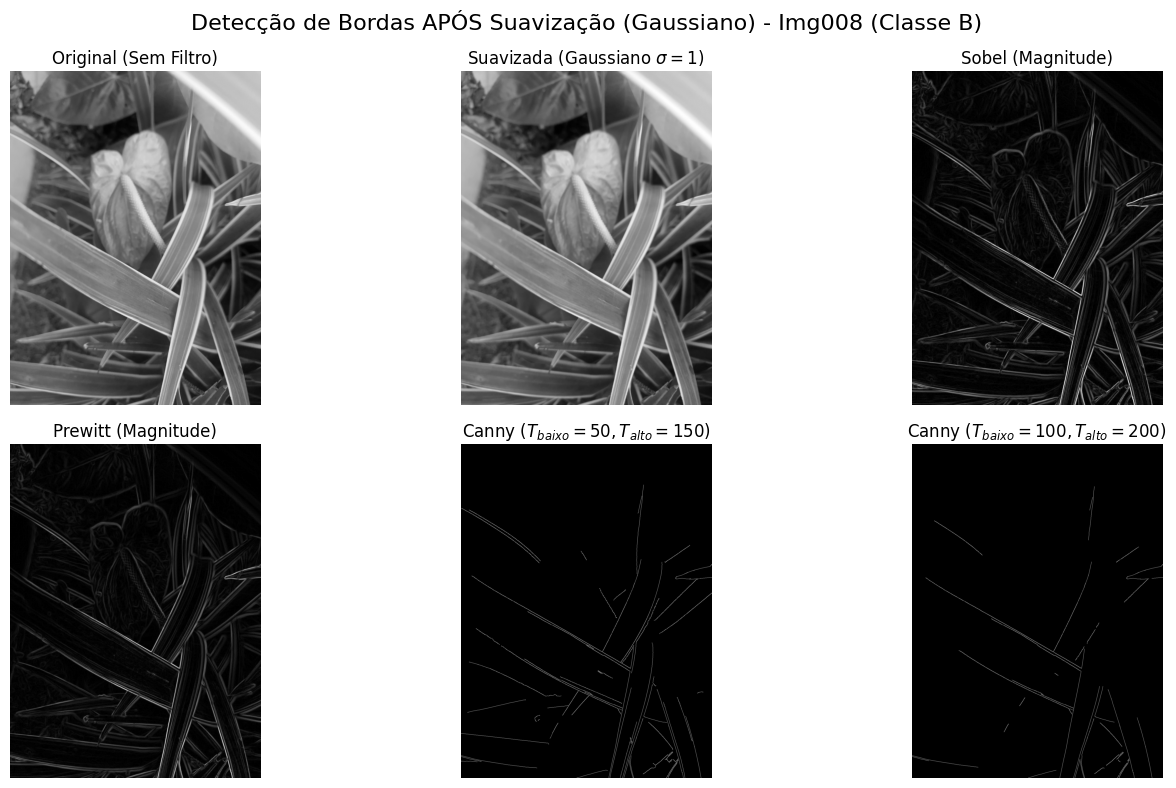

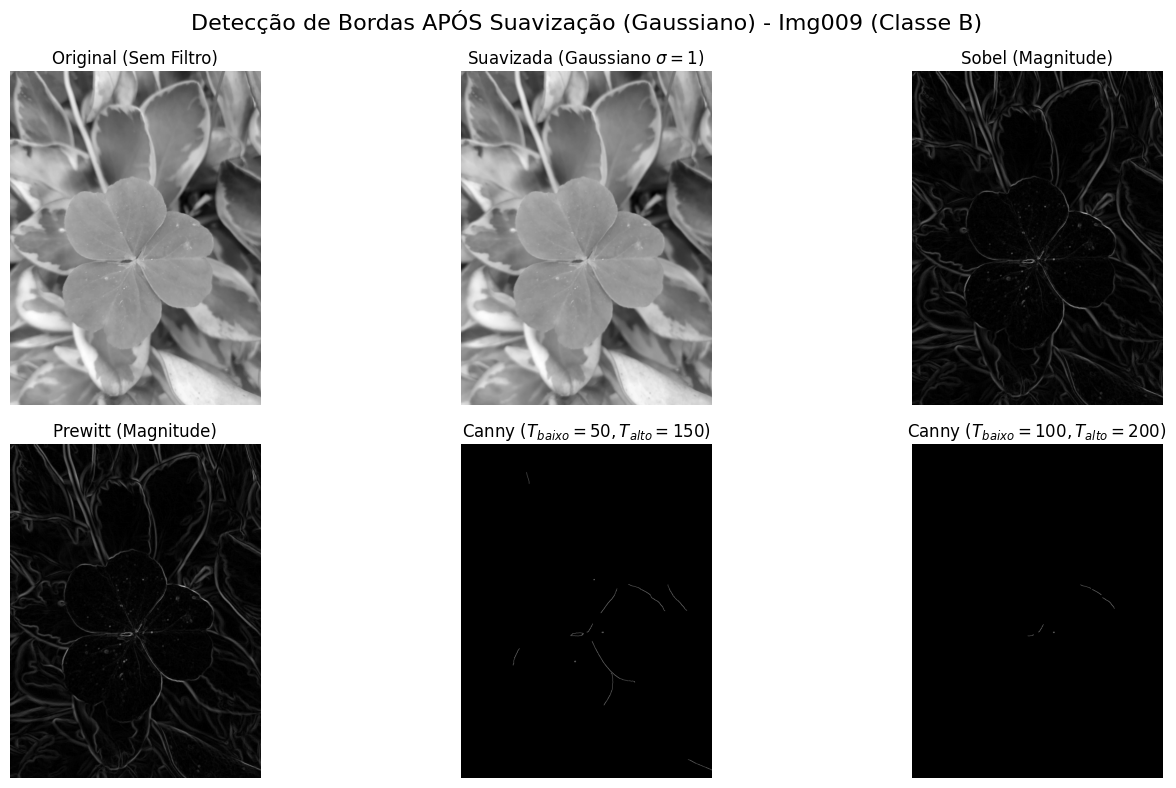

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Aplicando filtro Gaussiano (sigma=1) como o método escolhido
for idx, caminho in enumerate(caminhos):
    img = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
    if img is None: continue

    # 1. Aplicando a Suavização Prévia (Filtro Gaussiano)
    img_suavizada = cv2.GaussianBlur(img, (0, 0), sigmaX=1)

    # 2. Reaplicando Sobel na imagem suavizada
    sobel_x_64 = cv2.Sobel(img_suavizada, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y_64 = cv2.Sobel(img_suavizada, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = cv2.convertScaleAbs(cv2.magnitude(sobel_x_64, sobel_y_64))

    # 3. Reaplicando Prewitt na imagem suavizada
    kernel_prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
    kernel_prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
    prewitt_x_64 = cv2.filter2D(img_suavizada, cv2.CV_64F, kernel_prewitt_x)
    prewitt_y_64 = cv2.filter2D(img_suavizada, cv2.CV_64F, kernel_prewitt_y)
    prewitt_mag = cv2.convertScaleAbs(cv2.magnitude(prewitt_x_64, prewitt_y_64))

    # 4. Reaplicando Canny na imagem suavizada
    canny_baixo = cv2.Canny(img_suavizada, 50, 150)
    canny_alto = cv2.Canny(img_suavizada, 100, 200)

    # 5. Visualização Comparativa
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Detecção de Bordas APÓS Suavização (Gaussiano) - {nomes_imagens[idx]}", fontsize=16)

    axes[0, 0].imshow(img, cmap='gray'); axes[0, 0].set_title('Original (Sem Filtro)')
    axes[0, 1].imshow(img_suavizada, cmap='gray'); axes[0, 1].set_title('Suavizada (Gaussiano $\sigma=1$)')
    axes[0, 2].imshow(sobel_mag, cmap='gray'); axes[0, 2].set_title('Sobel (Magnitude)')

    axes[1, 0].imshow(prewitt_mag, cmap='gray'); axes[1, 0].set_title('Prewitt (Magnitude)')
    axes[1, 1].imshow(canny_baixo, cmap='gray'); axes[1, 1].set_title('Canny ($T_{baixo}=50, T_{alto}=150$)')
    axes[1, 2].imshow(canny_alto, cmap='gray'); axes[1, 2].set_title('Canny ($T_{baixo}=100, T_{alto}=200$)')

    for ax in axes.flat: ax.axis('off')
    plt.tight_layout()
    plt.show()

## Parte 4 - Detecção de Bordas após Suavização e Conclusão

**Filtro Escolhido:** Filtro Gaussiano ($\sigma=1$).
**Justificativa:** Conforme avaliado na Parte 2, o Filtro Gaussiano atribui maior peso aos pixels centrais, garantindo uma atenuação suave e contínua que reduz o ruído térmico/granulação sem causar o borramento excessivo das estruturas reais das folhagens, diferentemente do Filtro da Média[cite: 2].

### Comparativo: Antes vs. Depois da Suavização
* **Quantidade de bordas detectadas:** Houve uma redução expressiva na quantidade total de gradientes detectados. A suavização atuou como um filtro passa-baixa, eliminando as variações abruptas causadas pelo ruído e permitindo que os operadores focassem apenas nas descontinuidades estruturais macroscópicas da cena[cite: 2].
* **Redução de bordas falsas:** A eliminação de bordas falsas foi altamente satisfatória. Nos métodos de Sobel e Prewitt, a "poeira" brilhante presente no fundo da imagem desapareceu.
* **Continuidade das bordas reais:** O algoritmo de Canny, aliado à suavização Gaussiana prévia, garantiu uma excelente continuidade das bordas. Como o ruído de fundo foi suprimido, a etapa de limiarização por histerese do Canny pôde conectar os contornos fracos das folhas aos contornos fortes sem se desviar para gradientes gerados por granulação[cite: 2].

### Síntese Crítica e Sistêmica
1. **A suavização melhorou a detecção?** Sim, drasticamente. O pré-processamento provou ser uma etapa estratégica e essencial de controle da informação[cite: 2]. Ao alterar a distribuição estatística das imagens e remover altas frequências indesejadas, a suavização evitou que os modelos matemáticos diferencias confundissem ruído com estrutura[cite: 2].
2. **Qual operador foi mais robusto ao ruído?** O detector de **Canny**. Sua formulação como um problema de otimização (que engloba suavização, supressão de não-máximos e histerese) filtrou as flutuações e garantiu respostas únicas, ao contrário de Sobel e Prewitt, que apenas estimam a magnitude bruta do gradiente[cite: 2].
3. **Qual apresentou melhor definição estrutural?** O **Canny (com limiares $T_{baixo}=50, T_{alto}=150$)**. Ele entregou bordas finas de exato 1 pixel, precisamente localizadas e com as estruturas das folhas bem conectadas[cite: 2], enquanto Sobel e Prewitt produziram contornos espessos e difusos.

**Conclusão do Relatório:**
Este pipeline demonstrou na prática que a qualidade da saída em visão computacional depende fundamentalmente da preparação dos dados. O processamento linear espacial (Filtro Gaussiano) seguido por operadores diferenciais otimizados (Canny) formam a arquitetura mais robusta testada neste estudo para extração de características em imagens reais degradadas.